# Sparse Neuron Metrics

Side-by-side эксперимент для классификатора и детектора: вместо средней дельты по важным нейронам смотрим хвостовые признаки по одинаковому percent sweep. Шаг sweep: `0.1%` нейронов. Пороги подбираются на stratified train split и применяются на test split. Для detector в колонке `best_balanced_accuracy` используется обычный `best_accuracy`, потому что классы теперь сбалансированы.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "ClassifierDetectorExperiments":
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "ClassifierDetectorExperiments"))

from side_by_side_analysis import (
    compute_or_load_sparse_neuron_metrics,
    plot_sparse_count_threshold_quality,
    plot_sparse_top_window_quality,
    plot_sparse_percent_mean_quality,
    plot_sparse_extra_quality,
    plot_sparse_metric_leaderboard,
    save_tables,
)

FORCE = False
SEED = 17
TEST_SIZE = 0.4
LAYER_NAME = "model.9"
TOP_COUNTS = (1, 2, 3, 5, 10)
TOP_PERCENTS = tuple(np.round(np.arange(0.1, 10.0 + 1e-9, 0.1), 1))
MAX_EXAMPLES = None

In [2]:
result = compute_or_load_sparse_neuron_metrics(
    REPO_ROOT,
    force=FORCE,
    layer_name=LAYER_NAME,
    top_counts=TOP_COUNTS,
    top_percents=TOP_PERCENTS,
    seed=SEED,
    test_size=TEST_SIZE,
    max_examples=MAX_EXAMPLES,
)
roots = result["roots"]
rows = result["rows"].copy()
quality = result["quality"].copy()
regression = result["regression"].copy()

print("loaded_from_cache:", result.get("loaded_from_cache"))
print("cache_path:", result.get("cache_path"))
print("rows:", rows.shape, "quality:", quality.shape, "regression:", regression.shape)
print("top percent steps:", len(TOP_PERCENTS), TOP_PERCENTS[0], TOP_PERCENTS[-1])
for warning in result.get("warnings", []):
    print("WARNING:", warning)

loaded_from_cache: True
cache_path: /Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/cache/sparse_neuron_metrics_e1ad6d17781ca8f7.pkl
rows: (11489, 552) quality: (860, 39) regression: (1090, 11)
top percent steps: 100 0.1 10.0


In [3]:
display(
    quality.sort_values("best_balanced_accuracy", ascending=False)[
        [
            "source", "metric_family", "metric", "top_k", "top_percent",
            "best_balanced_accuracy", "balanced_recall", "balanced_specificity",
            "train_best_balanced_accuracy", "train_balanced_recall", "train_balanced_specificity",
            "balanced_threshold", "balanced_direction",
        ]
    ].head(30)
)
display(
    regression.sort_values("main_score", ascending=False)[
        ["source", "metric", "spearman", "pearson", "main_score", "n"]
    ].head(30)
)

,source,metric_family,metric,top_k,top_percent,best_balanced_accuracy,balanced_recall,balanced_specificity,train_best_balanced_accuracy,train_balanced_recall,train_balanced_specificity,balanced_threshold,balanced_direction
428,classifier,global_tail,all_delta_abs_p999,NaN,NaN,0.664016,0.576429,0.751603,0.671751,0.585214,0.758289,2.640232,1
147,classifier,top_percent_mean,top3p1pct_mean_abs_delta,NaN,3.1,0.656923,0.655193,0.658654,0.642747,0.663035,0.622460,0.098373,1
151,classifier,top_percent_mean,top3p2pct_mean_abs_delta,NaN,3.2,0.656779,0.658110,0.655449,0.641532,0.663813,0.619251,0.096834,1
737,detector,top_percent_mean,top7p1pct_mean_abs_delta,NaN,7.1,0.655799,0.755833,0.555766,0.646523,0.738889,0.554156,0.269621,1
701,detector,top_percent_mean,top6p2pct_mean_abs_delta,NaN,6.2,0.655581,0.745000,0.566163,0.646412,0.731111,0.561713,0.276065,1
653,detector,top_percent_mean,top5pct_mean_abs_delta,NaN,5.0,0.654941,0.747500,0.562382,0.648634,0.735556,0.561713,0.289372,1
661,detector,top_percent_mean,top5p2pct_mean_abs_delta,NaN,5.2,0.654717,0.750833,0.558601,0.649190,0.736667,0.561713,0.286642,1
573,detector,top_percent_mean,top3pct_mean_abs_delta,NaN,3.0,0.654519,0.760833,0.548204,0.646800,0.748889,0.544710,0.315581,1
155,classifier,top_percent_mean,top3p3pct_mean_abs_delta,NaN,3.3,0.654445,0.653442,0.655449,0.643330,0.659922,0.626738,0.096040,1
31,classifier,top_percent_mean,top0p2pct_mean_abs_delta,NaN,0.2,0.654413,0.722287,0.586538,0.639603,0.728405,0.550802,0.060782,1


,source,metric,spearman,pearson,main_score,n
1,classifier,all_delta_abs_p999,0.558826,0.502688,0.558826,5843
0,classifier,all_delta_abs_p99,0.483836,0.416119,0.483836,5843
2,classifier,all_delta_abs_max,0.477444,0.440467,0.477444,5843
532,classifier,top9p8pct_mean_abs_delta,0.382678,0.299220,0.382678,5843
542,classifier,top10pct_mean_abs_delta,0.382668,0.299755,0.382668,5843
537,classifier,top9p9pct_mean_abs_delta,0.382608,0.299405,0.382608,5843
527,classifier,top9p7pct_mean_abs_delta,0.382509,0.298998,0.382509,5843
522,classifier,top9p6pct_mean_abs_delta,0.382281,0.298627,0.382281,5843
517,classifier,top9p5pct_mean_abs_delta,0.381966,0.298333,0.381966,5843
512,classifier,top9p4pct_mean_abs_delta,0.381843,0.298003,0.381843,5843


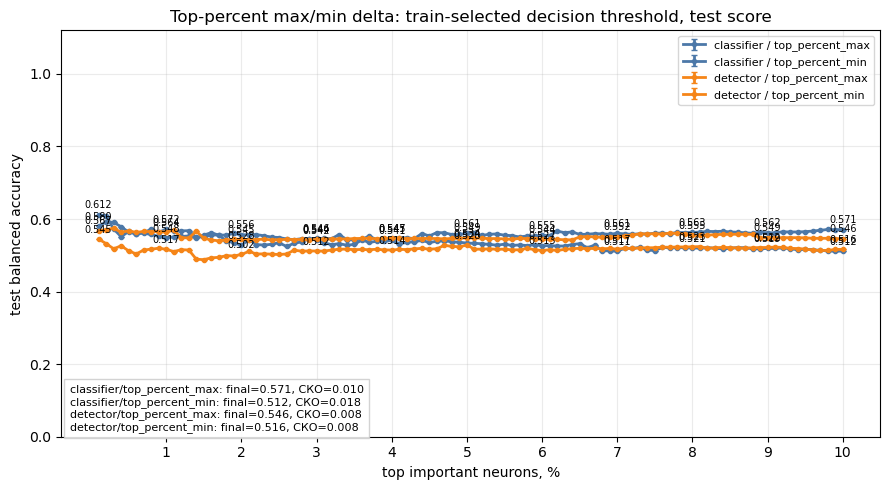

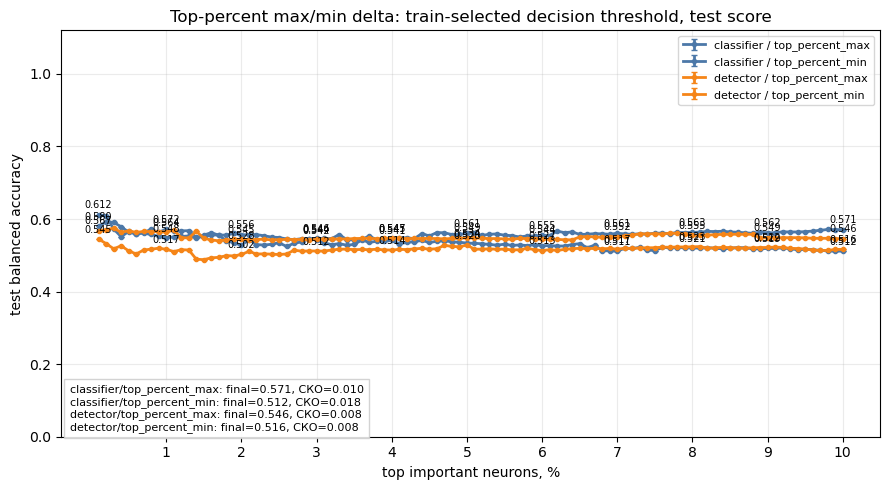

In [4]:
fig = plot_sparse_top_window_quality(quality)
fig.savefig(roots.comparison_output / "sparse_neuron_top_percent_max_min_quality.png", dpi=160, bbox_inches="tight")
fig

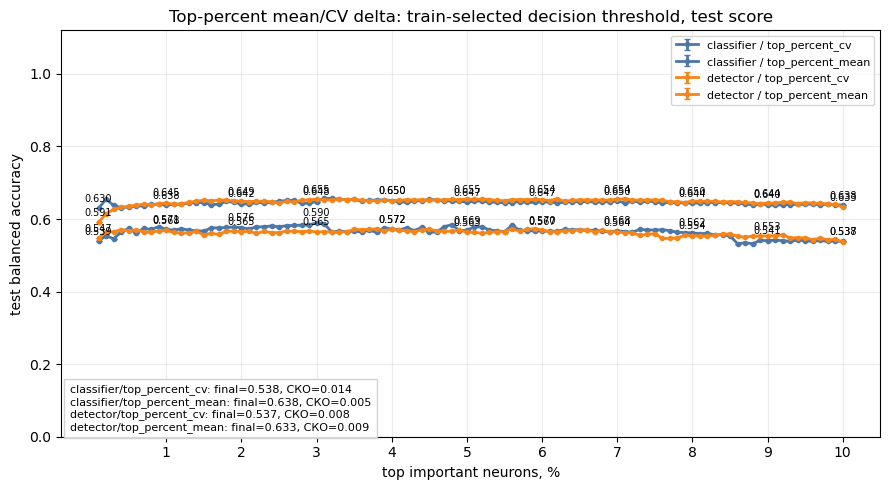

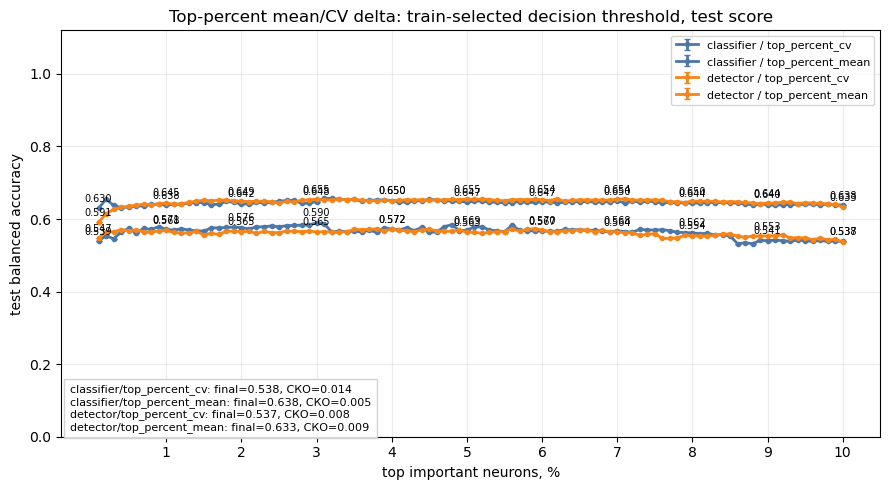

In [5]:
fig = plot_sparse_percent_mean_quality(quality)
fig.savefig(roots.comparison_output / "sparse_neuron_top_percent_mean_cv_quality.png", dpi=160, bbox_inches="tight")
fig

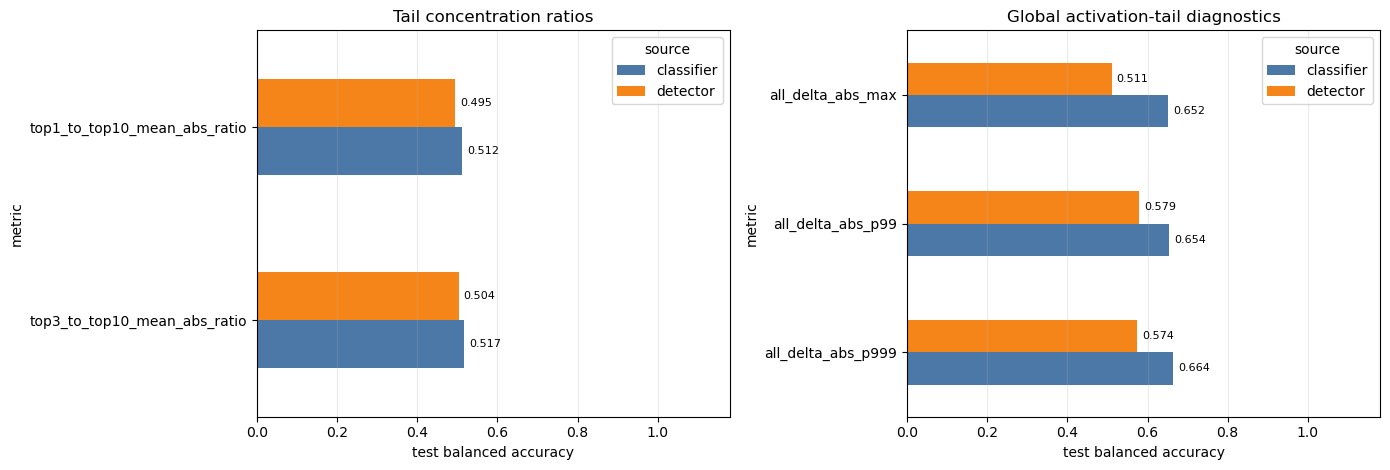

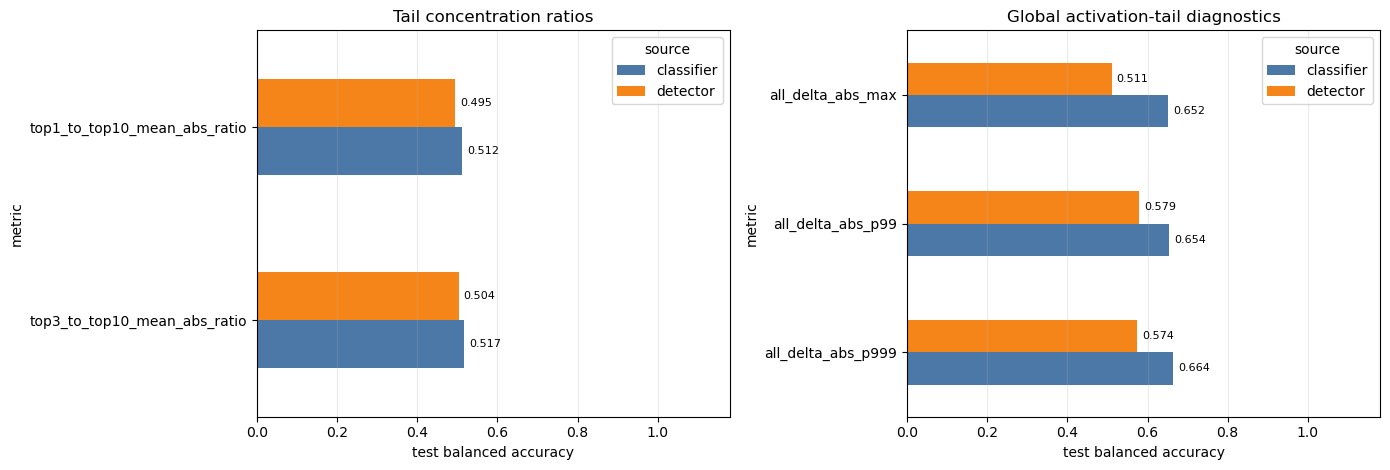

In [6]:
fig = plot_sparse_extra_quality(quality)
fig.savefig(roots.comparison_output / "sparse_neuron_extra_quality.png", dpi=160, bbox_inches="tight")
fig

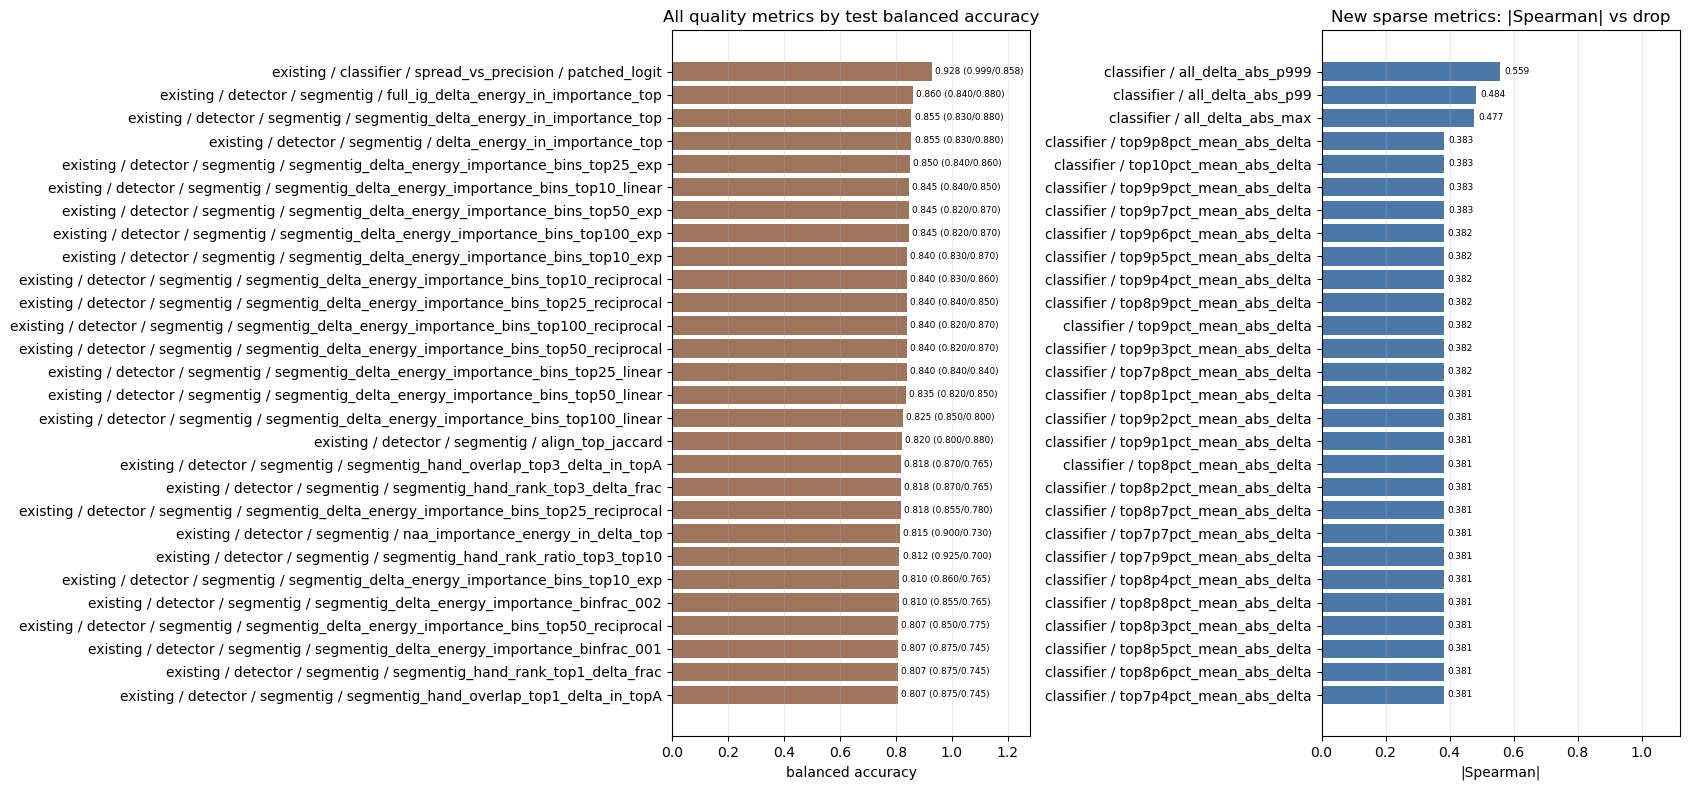

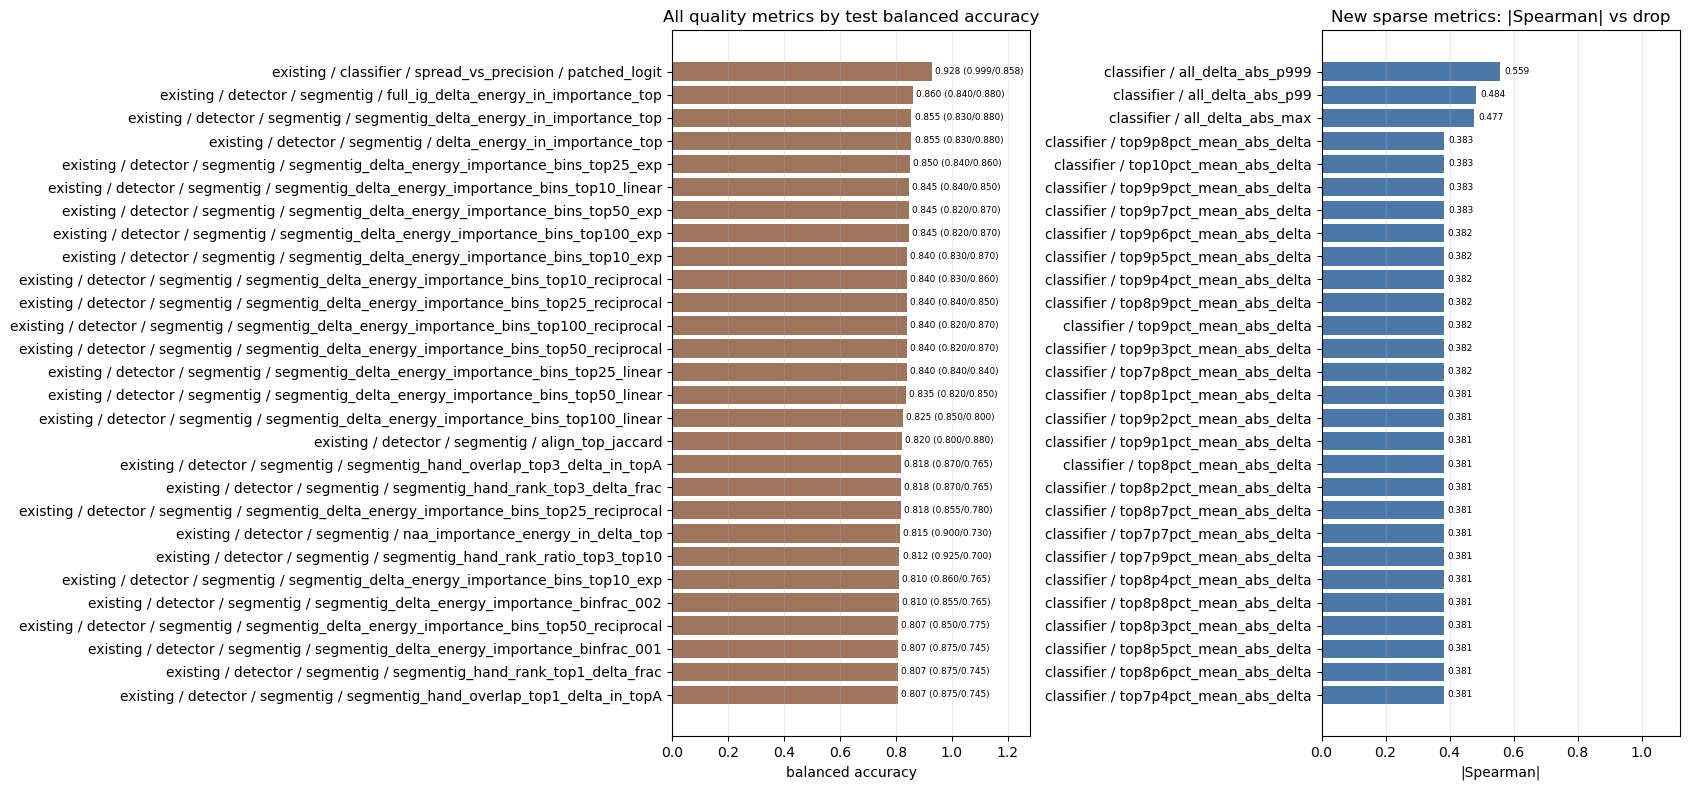

In [7]:
existing_quality_path = roots.comparison_output / "all_metrics_quality.csv"
existing_quality = pd.read_csv(existing_quality_path) if existing_quality_path.exists() else pd.DataFrame()
fig = plot_sparse_metric_leaderboard(
    quality,
    regression,
    existing_quality=existing_quality,
    top_n=28,
)
fig.savefig(roots.comparison_output / "sparse_neuron_all_metrics_leaderboard.png", dpi=160, bbox_inches="tight")
fig

In [ ]:
save_tables({"quality": quality, "regression": regression, "rows": rows}, roots.comparison_output, prefix="sparse_neuron")
print("saved to:", roots.comparison_output)

saved to: /Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs


: 